# **Transformations - Translations and Rotations**

## Objectives:
1. Perform Image Translations
2. Rotations with getRotationMatrix2D
3. Rotations with Transpose
4. Flipping Images

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

### The matrix is just "where does each pixel go"

`cv2.warpAffine` doesn't move the image directly — it takes a 2×3 matrix and, for *every* pixel coordinate `(x, y)` in the output, asks "which input coordinate maps here?" The translation matrix

$$T = \begin{bmatrix} 1 & 0 & T_x \\ 0 & 1 & T_y \end{bmatrix}$$

multiplies out to `x' = x + Tx`, `y' = y + Ty` — the `1`s just copy the coordinate through unchanged, and the third column is the actual shift. Every affine transform in OpenCV (translate, rotate, scale, shear) is this same 2×3 recipe with different numbers in it; that consistency is exactly why one function (`warpAffine`) handles all of them.

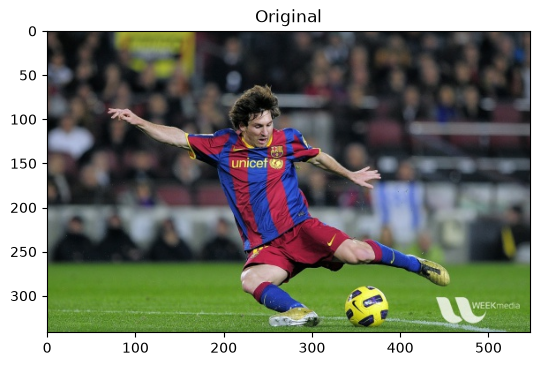

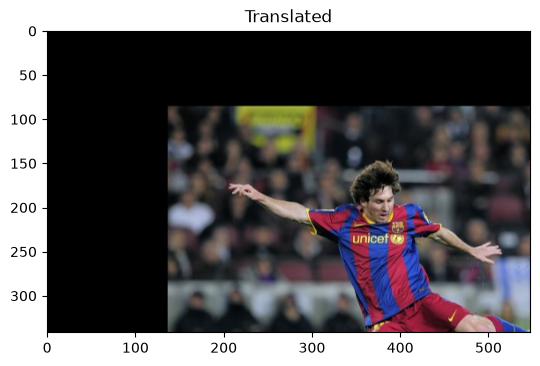

In [2]:
# Load our image
image = cv2.imread('assets/images/messi5.jpg')
imshow("Original", image)

# Store height and width of the image
height, width = image.shape[:2]

# We shift it by quarter of the height and width
quarter_height, quarter_width = height/4, width/4

# Our Translation
#       | 1 0 Tx |
#  T  = | 0 1 Ty |

# T is our translation matrix
T = np.float32([[1, 0, quarter_width], [0, 1,quarter_height]])

# We use warpAffine to transform the image using the matrix, T
img_translation = cv2.warpAffine(image, T, (width, height))
imshow("Translated", img_translation)

In [3]:
# What does T look like
print(T)

print(height, width )

[[  1.    0.  137. ]
 [  0.    1.   85.5]]
342 548


### Where the rotation matrix comes from

Rotating a point by angle θ around the origin is:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}$$

— at θ=0 that's the identity (cos 0=1, sin 0=0, nothing moves); as θ grows, each point swings around the origin along a circle. The catch: *around the origin* means corner `(0,0)`, so rotating an image with just this matrix sends it spinning off into negative coordinates. `cv2.getRotationMatrix2D((cx, cy), angle, scale)` fixes that by rotating around whatever center you give it (usually the image's own center) and folds a **scale factor** into the same matrix for free — that's why `scale=0.5` in the next cell both rotates *and* shrinks in one warp instead of two.

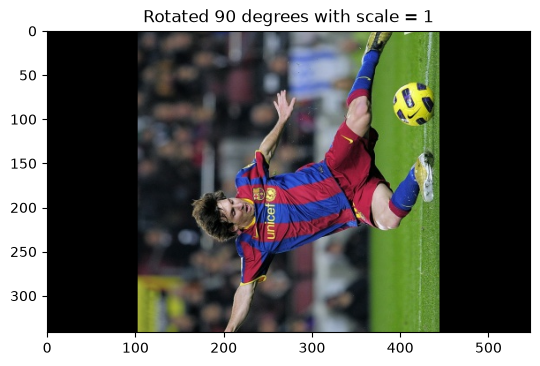

In [4]:
# Load our image
image = cv2.imread('assets/images/messi5.jpg')
height, width = image.shape[:2]

# Divide by two to rototate the image around its centre
rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), 90, 1)

# Input our image, the rotation matrix and our desired final width and height
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
imshow("Rotated 90 degrees with scale = 1", rotated_image)

[[ 3.061617e-17  5.000000e-01  1.885000e+02]
 [-5.000000e-01  3.061617e-17  3.080000e+02]]


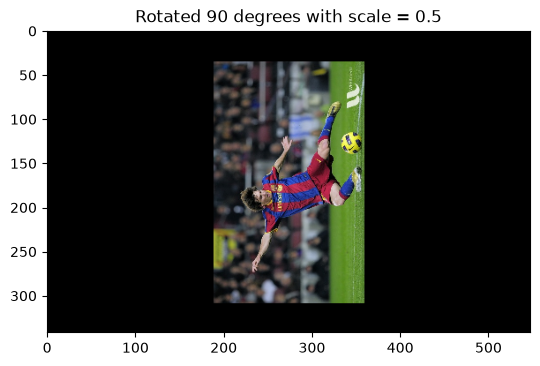

In [5]:
# Divide by two to rototate the image around its centre
rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), 90, 0.5)
print(rotation_matrix)
# Input our image, the rotation matrix and our desired final width and height
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
imshow("Rotated 90 degrees with scale = 0.5", rotated_image)

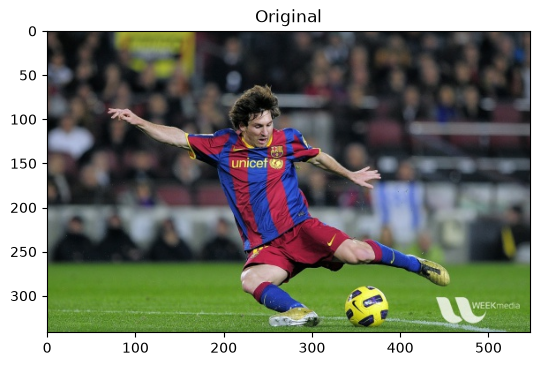

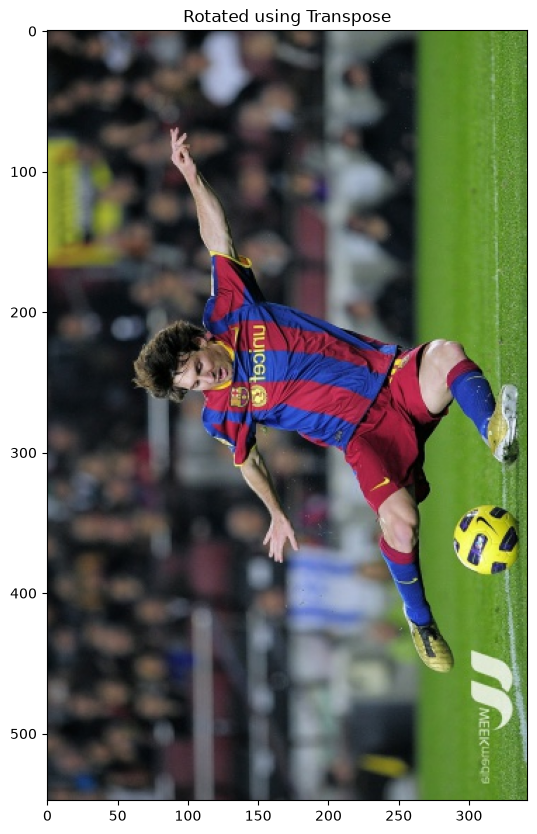

In [6]:
# cv2.transpose may be less flexible but can still be used for Rotations
rotated_image = cv2.transpose(image)
imshow("Original", image)
imshow("Rotated using Transpose", rotated_image)

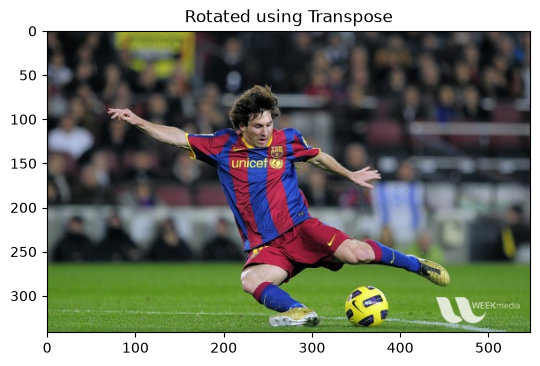

In [7]:
rotated_image = cv2.transpose(image)
rotated_image = cv2.transpose(rotated_image)

imshow("Rotated using Transpose", rotated_image)

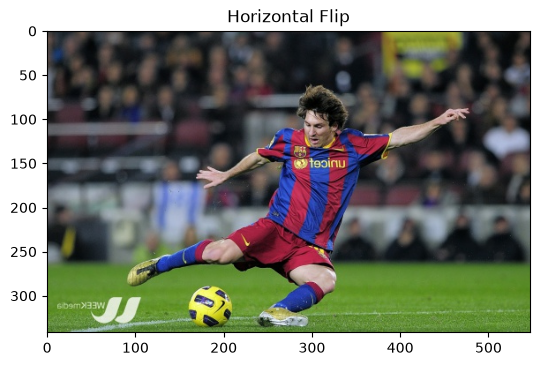

In [8]:
# Let's now to a horizontal flip.
flipped = cv2.flip(image, 1)
imshow("Horizontal Flip", flipped)

### A few ideas to play with

- `cv2.warpAffine` with an arbitrary rotation (not just 90°) leaves black corners — try `borderMode=cv2.BORDER_REFLECT` instead of the default and compare.
- Chain a translation and a rotation into a single affine matrix with `T @ R` (matrix multiply in homogeneous coordinates) instead of two `warpAffine` calls.